# SVM Classification — Reached.on.Time_Y.N

This notebook performs Support Vector Machine (SVM) classification to predict whether a shipment reached on time (`Reached.on.Time_Y.N`).

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

PLOT_DIR = '../plots/svm_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

## 2. Load Data

In [3]:
df = pd.read_csv('../assets/Train.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
df.head()

## 3. Exploratory Data Analysis

### 3.1 Correlation Matrix

                           ID  Customer_care_calls  Customer_rating  \
ID                   1.000000             0.188998        -0.005722   
Customer_care_calls  0.188998             1.000000         0.012209   
Customer_rating     -0.005722             0.012209         1.000000   
Cost_of_the_Product  0.196791             0.323182         0.009270   
Prior_purchases      0.145369             0.180771         0.013179   
Discount_offered    -0.598278            -0.130750        -0.003124   
Weight_in_gms        0.278312            -0.276615        -0.001897   
Reached.on.Time_Y.N -0.411822            -0.067126         0.013119   

                     Cost_of_the_Product  Prior_purchases  Discount_offered  \
ID                              0.196791         0.145369         -0.598278   
Customer_care_calls             0.323182         0.180771         -0.130750   
Customer_rating                 0.009270         0.013179         -0.003124   
Cost_of_the_Product             1.000000    

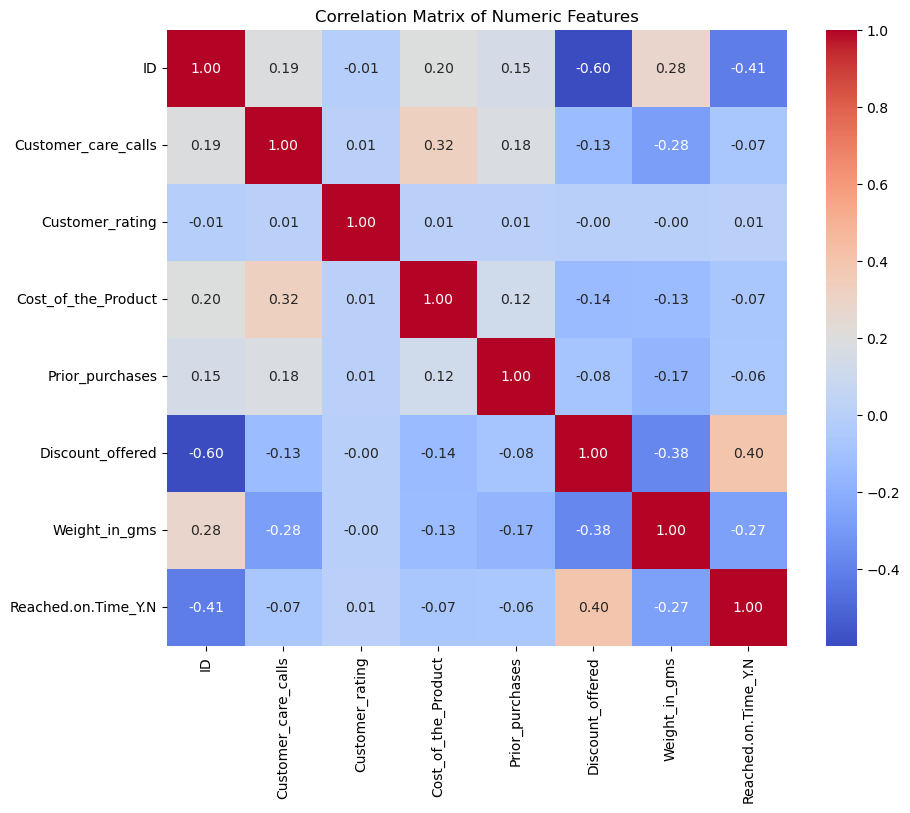

In [4]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64']).columns
numeric_df = df[numeric_cols]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Print correlation matrix
print(corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.savefig(os.path.join(PLOT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Target Variable Distribution

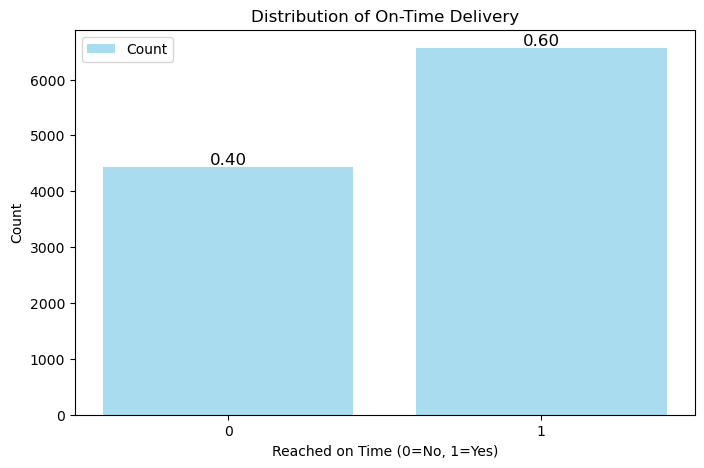

In [5]:
# Count occurrences of each class in the target
target_counts = df['Reached.on.Time_Y.N'].value_counts().sort_index()

# Compute probabilities
target_prob = target_counts / target_counts.sum()

# Plot counts
plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values, color='skyblue', alpha=0.7, label='Count')

# Overlay probabilities as text above bars
for i, (count, prob) in enumerate(zip(target_counts.values, target_prob.values)):
    plt.text(i, count + 50, f"{prob:.2f}", ha='center', fontsize=12)

plt.xlabel('Reached on Time (0=No, 1=Yes)')
plt.ylabel('Count')
plt.title('Distribution of On-Time Delivery')
plt.xticks([0, 1])
plt.legend()
plt.savefig(os.path.join(PLOT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [6]:
# Drop the ID column — unique identifier with no predictive value
df.drop(columns=['ID'], inplace=True)

# Fill missing values: median for numeric, mode for categorical
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Clip outliers using IQR method
for col in ['Customer_care_calls', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    df[col] = df[col].clip(Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1))

# Encode Gender as binary
df['Gender'] = (df['Gender'] == 'M').astype(int)

# Encode Product_importance as ordinal
df['Product_importance'] = df['Product_importance'].map({'low': 0, 'medium': 1, 'high': 2})

# One-hot encode Warehouse_block and Mode_of_Shipment
cat_dummies = pd.get_dummies(df[['Warehouse_block', 'Mode_of_Shipment']], drop_first=True).astype(float)

print("Preprocessing complete.")
df.head()

Preprocessing complete.


/var/folders/7s/szfb96hs5db4l9fb_5vdhxyh0000gn/T/ipykernel_5031/2615050966.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/7s/szfb96hs5db4l9fb_5vdhxyh0000gn/T/ipykernel_5031/2615050966.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,0,0,19,1233,1
1,F,Flight,4,5,216,2,0,1,19,3088,1
2,A,Flight,2,2,183,4,0,1,19,3374,1
3,B,Flight,3,3,176,4,1,1,10,1177,1
4,C,Flight,2,2,184,3,1,0,19,2484,1


In [7]:
# Define target and numeric features
target = 'Reached.on.Time_Y.N'
numeric_features = [
    'Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases',
    'Product_importance', 'Customer_rating', 'Gender',
    'Discount_offered', 'Weight_in_gms',
]

X_full = pd.concat([df[numeric_features], cat_dummies], axis=1)
y_full = df[target]

print(f"Full feature matrix shape: {X_full.shape}")
print(f"Features: {list(X_full.columns)}")

Full feature matrix shape: (10999, 14)
Features: ['Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Customer_rating', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship']


### 4.1 Class Balancing (Undersampling)

In [8]:
# Balance classes by undersampling the majority class
df_bal = X_full.copy()
df_bal[target] = y_full.values

minority = df_bal[df_bal[target] == 0]
majority = df_bal[df_bal[target] == 1].sample(n=len(minority), random_state=42)
balanced = pd.concat([minority, majority]).sample(frac=1, random_state=42)

X = balanced.drop(columns=[target])
y = balanced[target]

print(f"Balanced dataset shape: {X.shape}")
print(f"\nBalanced target distribution:\n{y.value_counts()}")

Balanced dataset shape: (8872, 14)

Balanced target distribution:
Reached.on.Time_Y.N
0    4436
1    4436
Name: count, dtype: int64


## 5. Train / Test Split & Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale only the continuous numeric columns
scale_cols = [
    'Customer_care_calls', 'Cost_of_the_Product', 'Prior_purchases',
    'Discount_offered', 'Weight_in_gms'
]
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7097 samples
Test set:     1775 samples

Training target distribution:
Reached.on.Time_Y.N
1    3549
0    3548
Name: count, dtype: int64

Test target distribution:
Reached.on.Time_Y.N
0    888
1    887
Name: count, dtype: int64


## 6. SVM Classification

In [10]:
# Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
print("RBF Kernel SVM")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rbf)}")

RBF Kernel SVM
Accuracy: 0.7104

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.77       888
           1       0.97      0.43      0.60       887

    accuracy                           0.71      1775
   macro avg       0.80      0.71      0.69      1775
weighted avg       0.80      0.71      0.69      1775



In [11]:
# Train SVM with Linear kernel for comparison
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
print("Linear Kernel SVM")
print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_linear)}")

Linear Kernel SVM
Accuracy: 0.6930

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.94      0.75       888
           1       0.89      0.44      0.59       887

    accuracy                           0.69      1775
   macro avg       0.76      0.69      0.67      1775
weighted avg       0.76      0.69      0.67      1775



## 7. Confusion Matrix

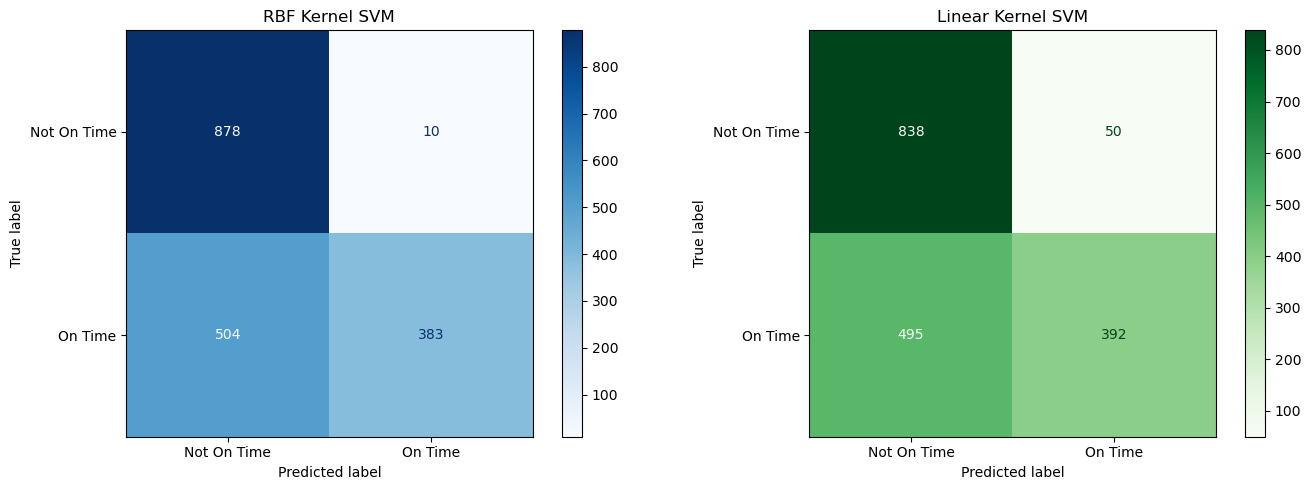

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RBF confusion matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=['Not On Time', 'On Time'])
disp_rbf.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('RBF Kernel SVM')

# Linear confusion matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=['Not On Time', 'On Time'])
disp_linear.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Linear Kernel SVM')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_rbf_linear.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Hyperparameter Tuning (GridSearchCV)

In [13]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV accuracy: 0.7157


In [ ]:
# Output the accuracy of all 5 folds for the best model
best_idx = grid_search.best_index_
print("Accuracy of all 5 folds:")
for i in range(5):
    fold_acc = grid_search.cv_results_[f'split{i}_test_score'][best_idx]
    print(f"Fold {i+1}: {fold_acc:.4f}")

Best SVM — Test Accuracy: 0.7166

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.97      0.77       888
           1       0.94      0.46      0.62       887

    accuracy                           0.72      1775
   macro avg       0.79      0.72      0.70      1775
weighted avg       0.79      0.72      0.70      1775



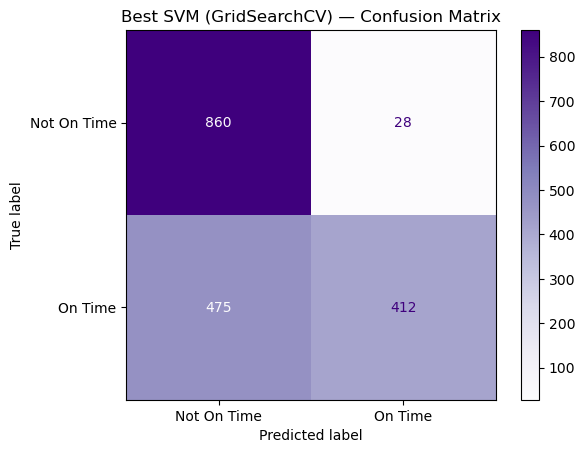

In [14]:
# Evaluate best model on test set
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

print(f"Best SVM — Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_best)}")

# Confusion matrix for best model
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Not On Time', 'On Time'])
disp_best.plot(cmap='Purples')
plt.title('Best SVM (GridSearchCV) — Confusion Matrix')
plt.savefig(os.path.join(PLOT_DIR, 'confusion_matrix_best.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC Curve

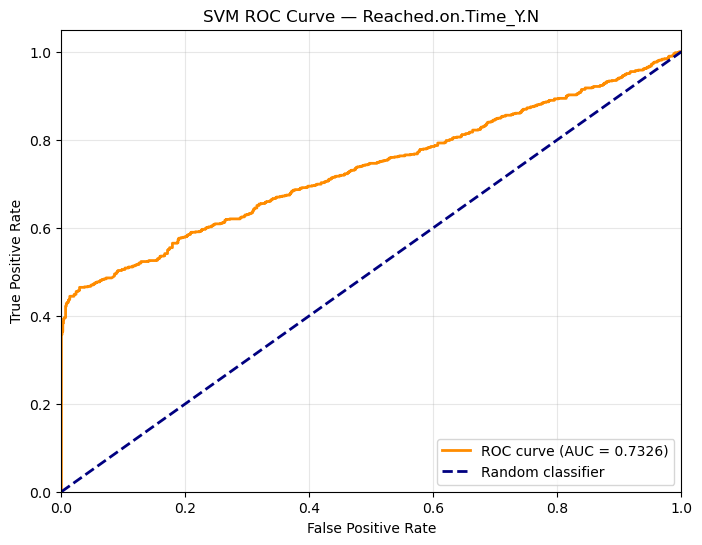

In [15]:
# Retrain best model with probability=True for ROC curve
svm_prob = SVC(
    **grid_search.best_params_,
    probability=True,
    random_state=42
)
svm_prob.fit(X_train, y_train)

y_prob = svm_prob.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve — Reached.on.Time_Y.N')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(PLOT_DIR, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Results Summary

In [16]:
# Summary table
results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'SVM (Linear)', f'SVM (Best: {grid_search.best_params_})'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_best)
    ],
    'AUC': [None, None, roc_auc]
})

print('=' * 70)
print('SVM Classification Results — Reached.on.Time_Y.N')
print('=' * 70)
print(results.to_string(index=False))

SVM Classification Results — Reached.on.Time_Y.N
                                                  Model  Accuracy      AUC
                                              SVM (RBF)  0.710423      NaN
                                           SVM (Linear)  0.692958      NaN
SVM (Best: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'})  0.716620 0.732588
